In [155]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
pd.options.mode.chained_assignment = None 

In [156]:
from py_af_colours import af_colours

In [157]:
# compare within lang1 <-> lang2 keep baseline vs augmented, model constant
lang_compare = pd.read_csv("among_lang_metrics.csv", index_col=0)

# compare within baseline <-> augmented keep lang, model  constant
baseline_compare = pd.read_csv("between_lang_baseline_metrics.csv", index_col=0)

# compare within gen1 <-> gen2 keep baseline vs augmented, model and lang constant
within_baseline_prompt = pd.read_csv("within_baseline_non_baseline.csv", index_col=0)

# compare within all language pairs baseline vs augmented, keep model constant
compare_all = pd.read_csv("all_comparisons.csv", index_col=0)

# retrieved docs metrics, within language
document_retrieved = pd.read_csv("reranked_docs_metrics.csv")

# compare retrieved to question, within language
document_retrieved_question = pd.read_csv("reranked_q_metrics.csv")

# compare retrieved chunks to answers, within language
document_retrieved_answer = pd.read_csv("reranked_answer_metrics.csv")

In [158]:
lang_compare["Model"] = ["-".join(x.split("-")[:2]) for x in lang_compare["Model"]]
baseline_compare["Model"] = ["-".join(x.split("-")[:2]) for x in baseline_compare["Model"]]
within_baseline_prompt["Model"] = ["-".join(x.split("-")[:2]) for x in within_baseline_prompt["Model"]]
compare_all["Model"] = ["-".join(x.split("-")[:2]) for x in compare_all["Model"]]
document_retrieved["Model"] = ["-".join(x.split("-")[:2]) for x in document_retrieved["Model"]]
document_retrieved_question["Model"] = ["-".join(x.split("-")[:2]) for x in document_retrieved_question["Model"]]
document_retrieved_answer["Model"] = ["-".join(x.split("-")[:2]) for x in document_retrieved_answer["Model"]]

In [159]:
models = ['Qwen3-4B', 'Qwen3-30B', 'Qwen3-235B']
metrics = ["Cosine", "Rouge"]
languages = list(baseline_compare["Language"].unique())
lang_pairs = list(lang_compare["Language1-Language2"].unique())
questions = list(lang_compare["Question"].unique())

In [160]:
models

['Qwen3-4B', 'Qwen3-30B', 'Qwen3-235B']

In [161]:
lang_compare.drop("Question", axis=1).groupby(["Model","Language1-Language2", "fBaseline"]).agg(['mean', 'std', 'count'])

Cosine                
                                              mean       std count
Model      Language1-Language2 fBaseline                          
Qwen3-235B EN-FR               False      0.811007  0.077964  1000
                               True       0.871138  0.036867  1000
           EN-NL               False      0.769388  0.089075  1000
                               True       0.883389  0.048565  1000
           FR-NL               False      0.739875  0.079948  1000
                               True       0.828495  0.047428  1000
Qwen3-30B  EN-FR               False      0.784818  0.102955  1000
                               True       0.874592  0.034630  1000
           EN-NL               False      0.754729  0.098110  1000
                               True       0.870667  0.049649  1000
           FR-NL               False      0.749899  0.073371  1000
                               True       0.820661  0.057202  1000
Qwen3-4B   EN-FR               False      0.740142  0.082293  1000
                               True       0.858091  0.048234  1000
           EN-NL               False      0.767717  0.105243  1000
                               True       0.855740  0.067873  1000
           FR-NL               False      0.662019  0.111893  1000
                               True       0.810785  0.067549  1000

In [162]:
lang_compare.groupby(["Model","Question","Language1-Language2", "fBaseline"]).agg(['mean', 'std', 'count'])

Cosine                
                                                         mean       std count
Model      Question   Language1-Language2 fBaseline                          
Qwen3-235B Question 1 EN-FR               False      0.889176  0.010365   100
                                          True       0.902254  0.012157   100
                      EN-NL               False      0.925568  0.018026   100
                                          True       0.940200  0.012157   100
                      FR-NL               False      0.864849  0.017660   100
...                                                       ...       ...   ...
Qwen3-4B   Question 9 EN-FR               True       0.836026  0.018948   100
                      EN-NL               False      0.651092  0.031999   100
                                          True       0.899921  0.014069   100
                      FR-NL               False      0.527326  0.038915   100
                                          True       0.818136  0.020519   100

[180 rows x 3 columns]

In [163]:
baseline_compare.drop("Question", axis=1).groupby(["Model", "Language"]).agg(["mean", "count"])

Cosine           Rouge      
                         mean count      mean count
Model      Language                                
Qwen3-235B EN        0.875661  1000  0.293794  1000
           FR        0.862302  1000  0.248929  1000
           NL        0.820478  1000  0.232411  1000
Qwen3-30B  EN        0.852890  1000  0.257680  1000
           FR        0.879329  1000  0.252227  1000
           NL        0.804091  1000  0.265829  1000
Qwen3-4B   EN        0.833977  1000  0.234597  1000
           FR        0.758826  1000  0.203855  1000
           NL        0.833013  1000  0.246281  1000

In [164]:
baseline_compare.groupby(["Model", "Question", "Language"]).agg(["mean", "count"])

Cosine           Rouge      
                                     mean count      mean count
Model      Question    Language                                
Qwen3-235B Question 1  EN        0.964572   100  0.541377   100
                       FR        0.910476   100  0.269589   100
                       NL        0.926017   100  0.320241   100
           Question 10 EN        0.802167   100  0.171835   100
                       FR        0.802203   100  0.202806   100
...                                   ...   ...       ...   ...
Qwen3-4B   Question 8  FR        0.599708   100  0.197693   100
                       NL        0.841095   100  0.236298   100
           Question 9  EN        0.679609   100  0.156293   100
                       FR        0.632775   100  0.174382   100
                       NL        0.844770   100  0.233242   100

[90 rows x 4 columns]

In [165]:
compare_all.groupby(["Model", "Question", "Language1-Language2"]).agg(["mean", "count"])

Cosine      
                                                mean count
Model      Question    Language1-Language2                
Qwen3-235B Question 1  EN-FR                0.884235   200
                       EN-NL                0.924094   200
                       FR-NL                0.860101   200
           Question 10 EN-FR                0.746046   200
                       EN-NL                0.797247   200
...                                              ...   ...
Qwen3-4B   Question 8  EN-NL                0.790607   200
                       FR-NL                0.676566   200
           Question 9  EN-FR                0.620852   200
                       EN-NL                0.754424   200
                       FR-NL                0.665566   200

[90 rows x 2 columns]

In [166]:
from pypalettes import load_cmap
palette = "Arches"
cmap = load_cmap(palette).colors

In [167]:
categorical = sns.color_palette([x for x in load_cmap(palette).colors if x!='#682C37FF'], 4)

In [168]:
SMALL_SIZE = 12
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

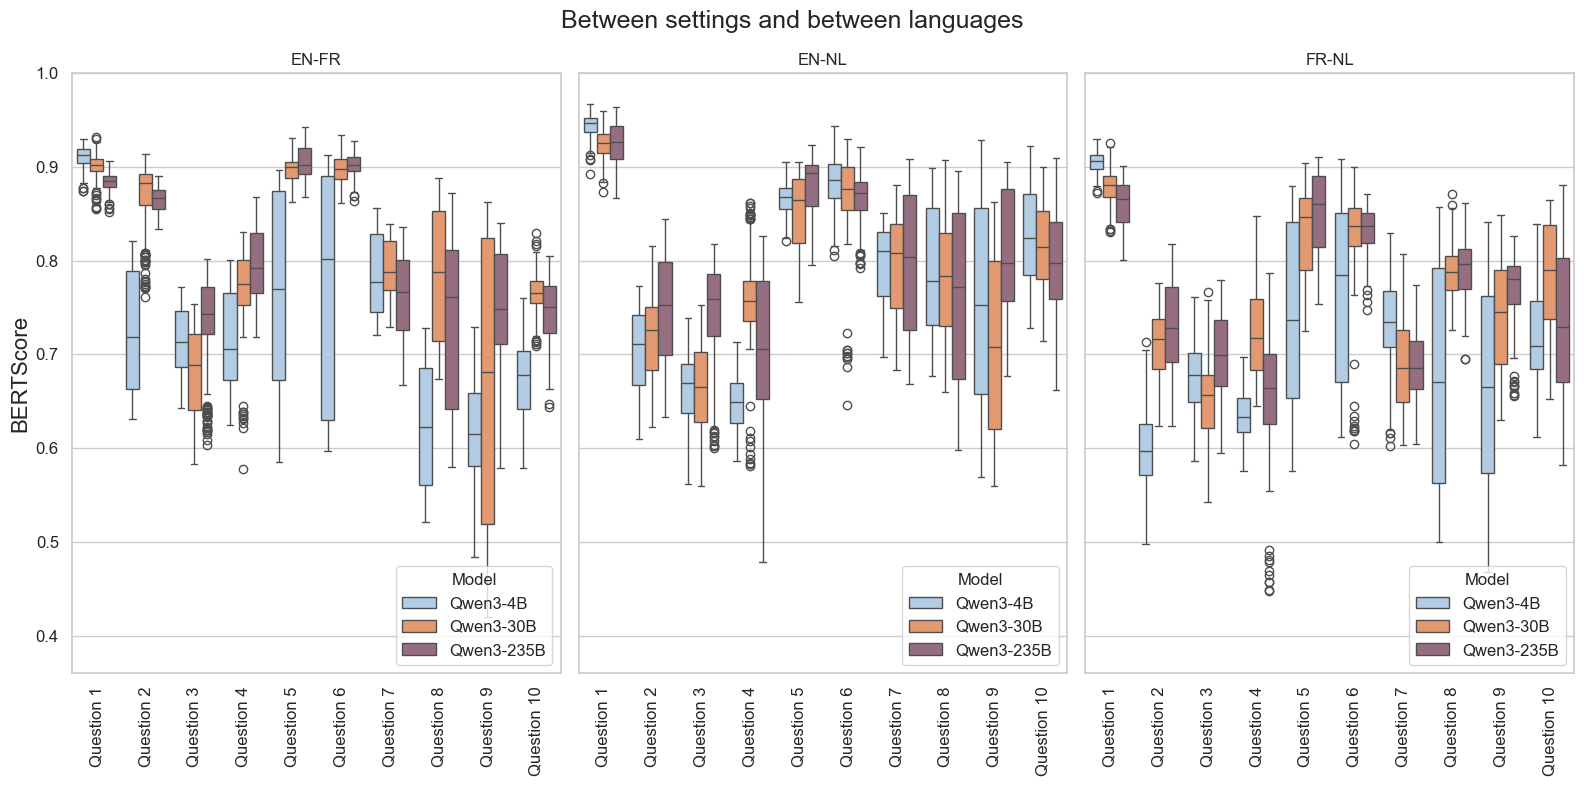

In [169]:
# std in scores between baseline and augmented per language per model
fig, axs = plt.subplots(ncols=len(lang_pairs), figsize=(16,8), sharey=True)
plt.suptitle("Between settings and between languages")
for i, lang_pair in enumerate(lang_pairs):
    subset = compare_all[compare_all['Language1-Language2']==lang_pair]
    subset['q_number'] = [int(i.split(' ')[1]) for i in subset['Question']]
    subset = subset.sort_values(by=['Model', 'q_number'], ascending=[False, True])
    subset = subset.rename(columns={"Cosine": "BERTScore"})

    axs[i].set_title(lang_pair)
    sns.boxplot(data=subset, x=subset["Question"].to_list(), y="BERTScore", hue="Model", palette=categorical, ax=axs[i])
    axs[i].set_ylim([0.36, 1])
    sns.move_legend(axs[i], 'lower right')
    axs[i].tick_params('x', labelrotation=90)
plt.tight_layout()
plt.savefig('figs/between-setting-between-language-between-question.svg')
plt.show()

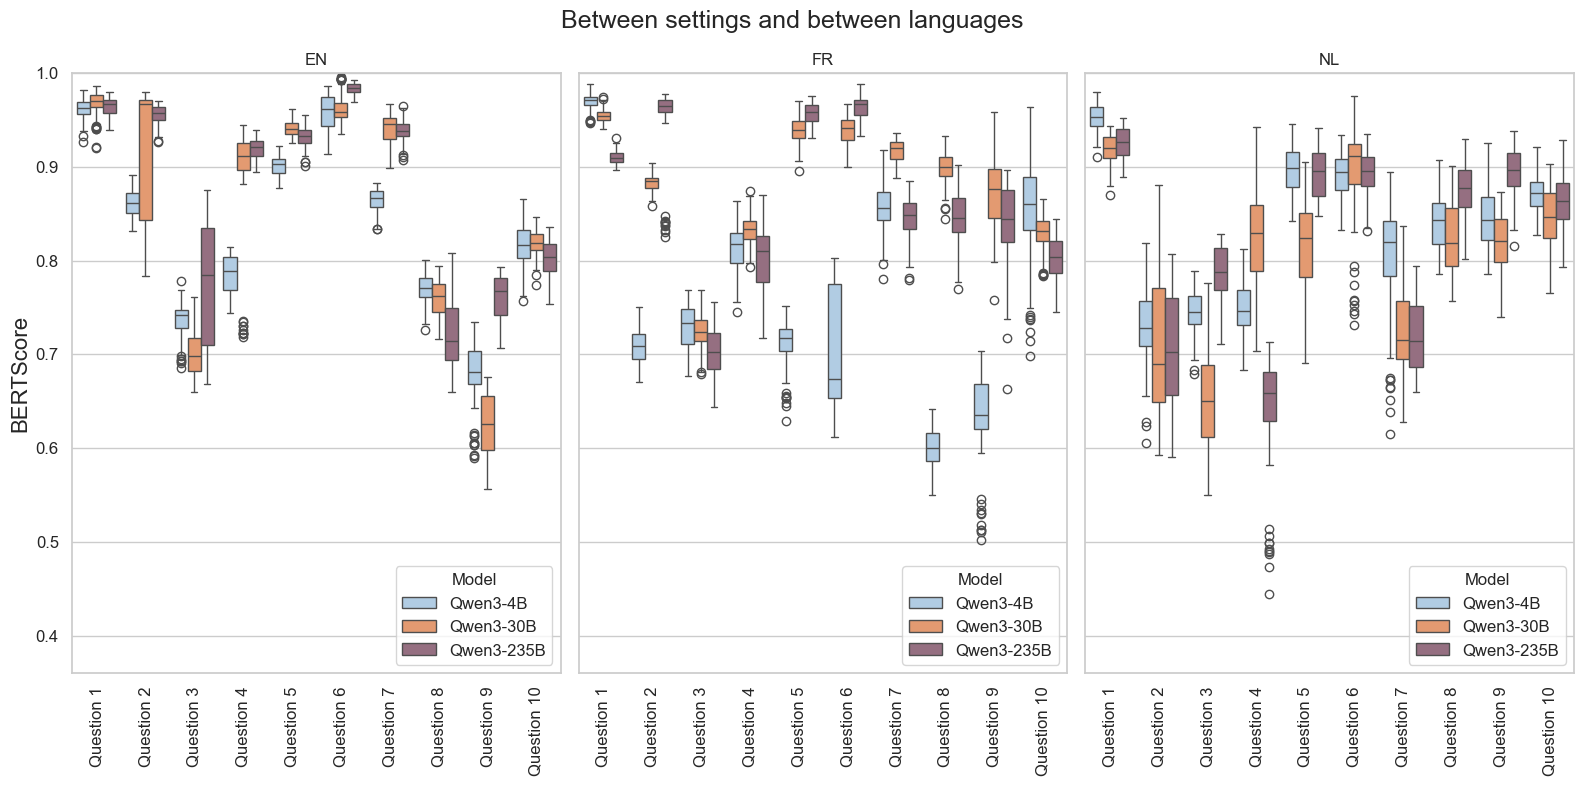

In [170]:
# std in scores between baseline and augmented per language per model
fig, axs = plt.subplots(ncols=len(languages), figsize=(16,8), sharey=True)
plt.suptitle("Between settings and between languages")
for i, lang_pair in enumerate(languages):
    subset = baseline_compare[baseline_compare['Language']==lang_pair]
    subset['q_number'] = [int(i.split(' ')[1]) for i in subset['Question']]
    subset = subset.sort_values(by=['Model', 'q_number'], ascending=[False, True])
    subset = subset.rename(columns={"Cosine": "BERTScore"})

    axs[i].set_title(lang_pair)
    sns.boxplot(data=subset, x=subset["Question"].to_list(), y="BERTScore", hue="Model", palette=categorical, ax=axs[i])
    axs[i].set_ylim([0.36, 1])
    sns.move_legend(axs[i], 'lower right')
    axs[i].tick_params('x', labelrotation=90)
plt.tight_layout()
plt.savefig('figs/between-setting-between-language-between-question.svg')
plt.show()

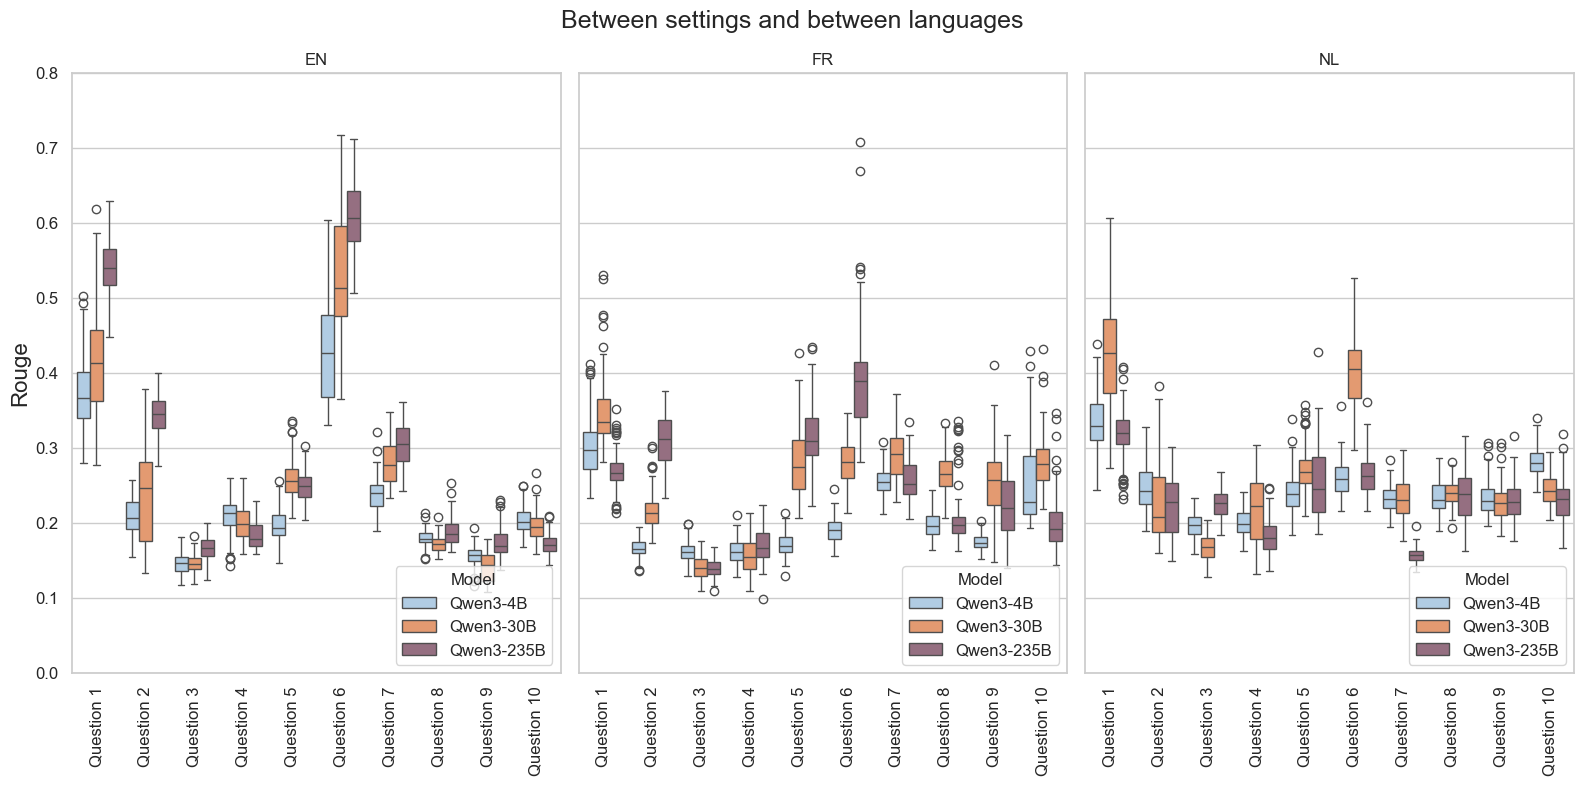

In [171]:
# std in scores between baseline and augmented per language per model
fig, axs = plt.subplots(ncols=len(languages), figsize=(16,8), sharey=True)
plt.suptitle("Between settings and between languages")
for i, lang_pair in enumerate(languages):
    subset = baseline_compare[baseline_compare['Language']==lang_pair]
    subset['q_number'] = [int(i.split(' ')[1]) for i in subset['Question']]
    subset = subset.sort_values(by=['Model', 'q_number'], ascending=[False, True])
    # subset = subset.rename(columns={"Cosine": "Rouge"})

    axs[i].set_title(lang_pair)
    sns.boxplot(data=subset, x=subset["Question"].to_list(), y="Rouge", hue="Model", palette=categorical, ax=axs[i])
    axs[i].set_ylim([0,0.8])
    sns.move_legend(axs[i], 'lower right')
    axs[i].tick_params('x', labelrotation=90)
plt.tight_layout()
plt.savefig('figs/between-setting-between-language-between-question.svg')
plt.show()

In [172]:
aggregations = []
for model in models:
    subset = baseline_compare[baseline_compare["Model"]==model]
    subset['q_number'] = [int(i.split(' ')[1]) for i in subset['Question']]
    subset = subset.drop(["Question"], axis=1)
    
    cosine_ = subset.groupby(by=["Language", "Model", "q_number"]).agg({'Cosine': ["mean", 'std']}).transform('Cosine').reset_index().drop("Model", axis=1)
    rouge_ = subset.groupby(by=["Language", "Model", "q_number"]).agg({'Rouge':['mean', 'std']}).transform('Rouge').reset_index().drop("Model", axis=1)
    rouge_["ROUGE"] = [f"{x:.2f}±{y:.2f}" for x,y in zip(rouge_['mean'], rouge_['std'])]
    cosine_["BERTScore"] = [f"{x:.2f}±{y:.2f}" for x,y in zip(cosine_['mean'], cosine_['std'])]
    rouge_.drop(["mean", "std"], axis=1, inplace=True)
    cosine_.drop(["mean", "std"], axis=1, inplace=True)
    merge = rouge_.merge(cosine_, on=["q_number", "Language"])
    print(model)
    merge = pd.melt(merge, id_vars=['Language', 'q_number'], value_vars=['ROUGE', 'BERTScore'])
    print(merge.pivot(index="q_number", columns=["Language", "variable"], values="value").sort_index(axis=1, level=[0, 1]))
    print()

Qwen3-4B
Language         EN                    FR                    NL           
variable  BERTScore      ROUGE  BERTScore      ROUGE  BERTScore      ROUGE
q_number                                                                  
1         0.96±0.01  0.38±0.05  0.97±0.01  0.30±0.04  0.95±0.01  0.33±0.04
2         0.86±0.01  0.21±0.02  0.71±0.02  0.17±0.01  0.73±0.04  0.25±0.03
3         0.74±0.02  0.15±0.01  0.73±0.02  0.16±0.01  0.75±0.02  0.20±0.02
4         0.79±0.02  0.21±0.02  0.81±0.03  0.16±0.02  0.75±0.03  0.20±0.02
5         0.90±0.01  0.20±0.02  0.71±0.02  0.17±0.01  0.90±0.02  0.24±0.03
6         0.96±0.02  0.43±0.06  0.70±0.06  0.19±0.02  0.89±0.02  0.26±0.02
7         0.86±0.01  0.24±0.02  0.86±0.03  0.26±0.02  0.80±0.06  0.23±0.02
8         0.77±0.02  0.18±0.01  0.60±0.02  0.20±0.02  0.84±0.03  0.24±0.02
9         0.68±0.03  0.16±0.01  0.63±0.04  0.17±0.01  0.84±0.03  0.23±0.02
10        0.82±0.02  0.20±0.02  0.86±0.06  0.25±0.06  0.87±0.02  0.28±0.02

Qwen3-30B
Langu

In [173]:
# new_df = aggregations[0].set_index("q_number").drop("Model", axis=1)
# new_df

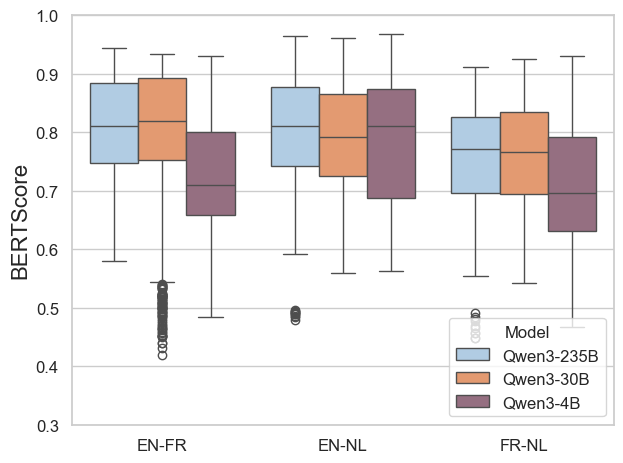

In [174]:
ax=sns.boxplot(data=compare_all.rename(columns={"Cosine":"BERTScore"}), x="Language1-Language2", y="BERTScore", hue="Model", palette=categorical)
sns.move_legend(ax, 'lower right')
plt.xlabel('')
# plt.title("Between settings and language")
plt.ylim([0.3, 1])
plt.tight_layout()
plt.savefig('figs/between-setting-between-language.svg')
plt.show()

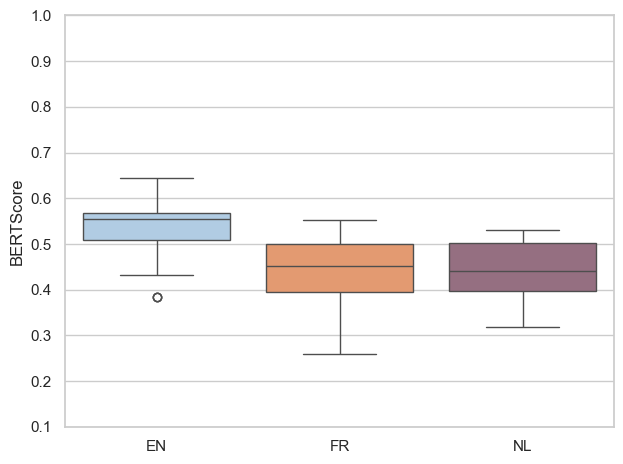

In [193]:
ax=sns.boxplot(data=document_retrieved.rename(columns={"Cosine":"BERTScore"}), x="Language", y="BERTScore", palette=categorical)
# sns.move_legend(ax, 'lower right')
plt.xlabel('')
# plt.title("Between settings and language")
plt.ylim([0.1, 1])
plt.tight_layout()
plt.savefig('figs/retrieved_docs.svg')
plt.show()

In [209]:
subset = document_retrieved_answer.drop(["Unnamed: 0","Model"], axis=1)
subset['q_number'] = [int(i.split(' ')[1]) for i in subset['Question']]
subset = subset.drop(["Question"], axis=1)

cosine_ = subset.groupby(by=["Language", "q_number"]).agg({'Cosine': ["mean", 'std']}).transform('Cosine').reset_index()
rouge_ = subset.groupby(by=["Language", "q_number"]).agg({'Rouge':['mean', 'std']}).transform('Rouge').reset_index()
rouge_["ROUGE"] = [f"{x:.2f}±{y:.2f}" for x,y in zip(rouge_['mean'], rouge_['std'])]
cosine_["BERTScore"] = [f"{x:.2f}±{y:.2f}" for x,y in zip(cosine_['mean'], cosine_['std'])]
rouge_.drop(["mean", "std"], axis=1, inplace=True)
cosine_.drop(["mean", "std"], axis=1, inplace=True)
merge = rouge_.merge(cosine_, on=["q_number", "Language"])
merge = pd.melt(merge, id_vars=['Language', 'q_number'], value_vars=['BERTScore'])
merge = merge.pivot(index="q_number", columns=["Language", "variable"], values="value").sort_index(axis=1, level=[0, 1])
merge

Language,EN,FR,NL
variable,BERTScore,BERTScore,BERTScore
q_number,,,
1,0.55±0.03,0.39±0.06,0.45±0.08
2,0.57±0.06,0.32±0.05,0.39±0.08
3,0.57±0.06,0.39±0.07,0.40±0.06
4,0.51±0.08,0.43±0.08,0.43±0.06
5,0.62±0.03,0.52±0.04,0.47±0.07
6,0.50±0.05,0.42±0.05,0.39±0.03
7,0.62±0.07,0.54±0.08,0.47±0.04
8,0.52±0.05,0.42±0.05,0.51±0.10


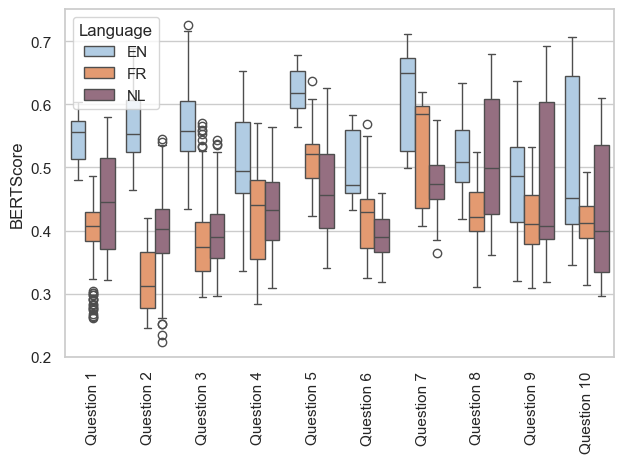

In [212]:
ax=sns.boxplot(data=document_retrieved_answer.rename(columns={"Cosine":"BERTScore"}), x="Question", y="BERTScore", hue="Language", palette=categorical)
# sns.move_legend(ax, 'lower right')
plt.xlabel('')
plt.xticks(rotation=90)
# plt.title("Between settings and language")
# plt.ylim([, 1])
plt.tight_layout()
plt.savefig('figs/retrieved_docs_answer.svg')
plt.show()

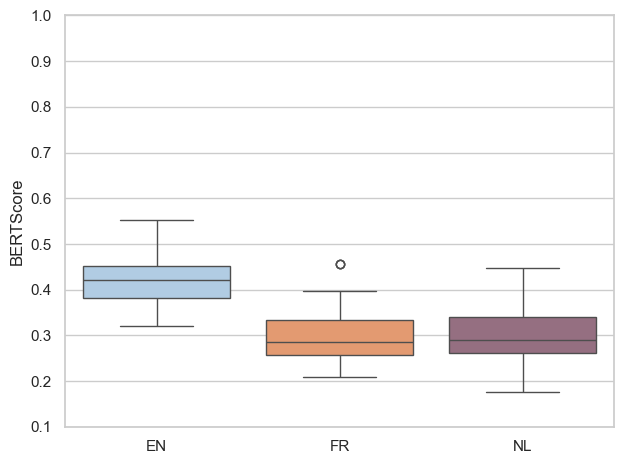

In [194]:
ax=sns.boxplot(data=document_retrieved_question.rename(columns={"Cosine":"BERTScore"}), x="Language", y="BERTScore", palette=categorical)
# sns.move_legend(ax, 'lower right')
plt.xlabel('')
# plt.title("Between settings and language")
plt.ylim([0.1, 1])
plt.tight_layout()
plt.savefig('figs/retrieved_docs_question.svg')
plt.show()

In [178]:
categorical = sns.color_palette(cmap, 2)  
categorical.sort()

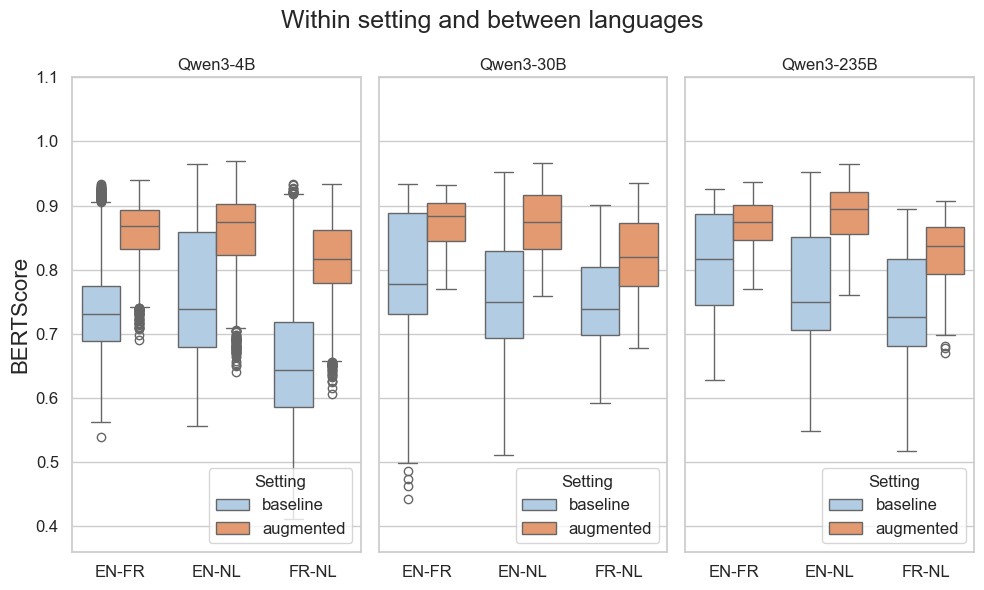

In [179]:
# std in scores amongst baseline condition and amongst augmented conditnion per language pair per model
# when looking at augmented condition, the IQR is smaller in almost all cases,
# mean that bertscore is more consistent -> more similar answers in all language pairs

fig, axs = plt.subplots(ncols=len(models), figsize=(10,6), sharey=True)
plt.suptitle("Within setting and between languages")
for i, model in enumerate(models):
    axs[i].set_title(model)
    axs[i].set_ylim([0.36, 1.1])
    test = lang_compare[(lang_compare["Model"]==model)]
    test = test.rename(columns={"Cosine": "BERTScore"})

    test["Setting"] = ["augmented" if x else "baseline" for x in test["fBaseline"]]
    ax=sns.boxplot(x=test["Language1-Language2"].to_list(), y="BERTScore", hue="Setting", data=test, ax=axs[i], palette=categorical)
    sns.move_legend(axs[i], 'lower right')
plt.tight_layout()
plt.savefig('figs/within-setting-between-languages.svg')
plt.show()

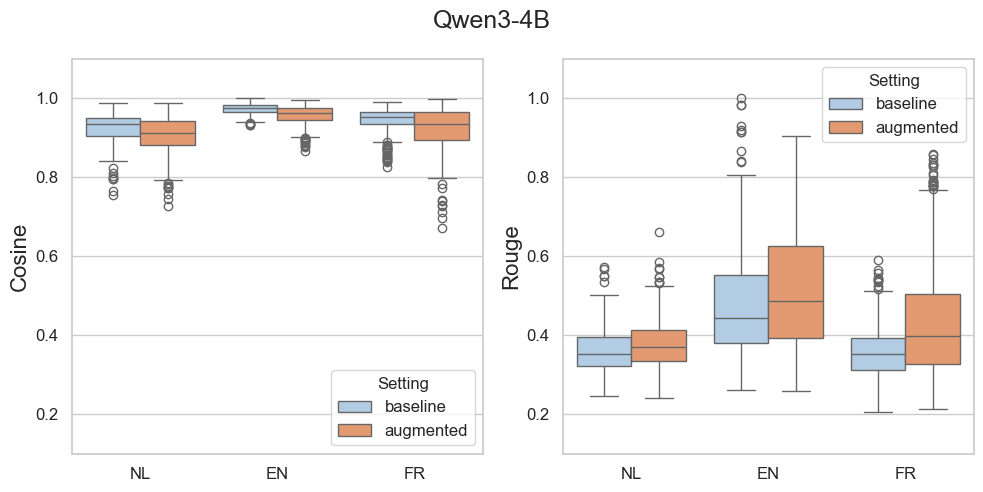

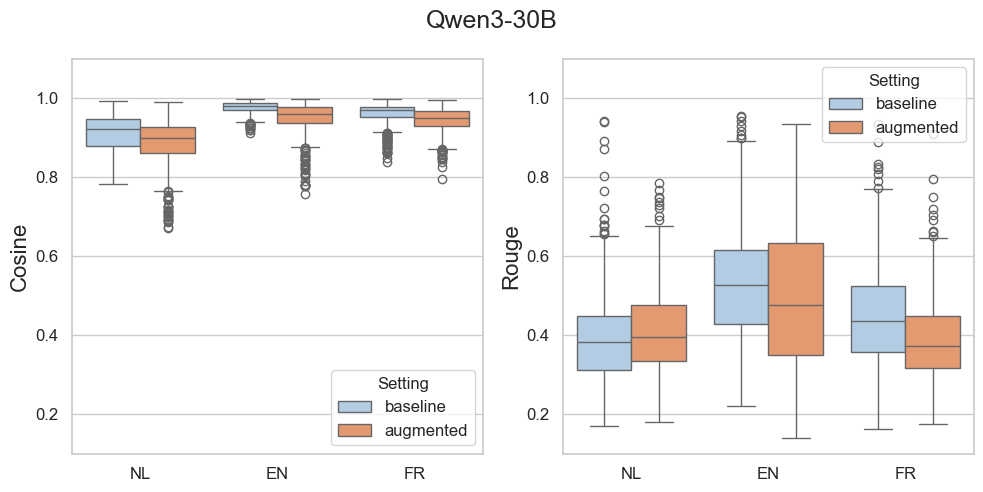

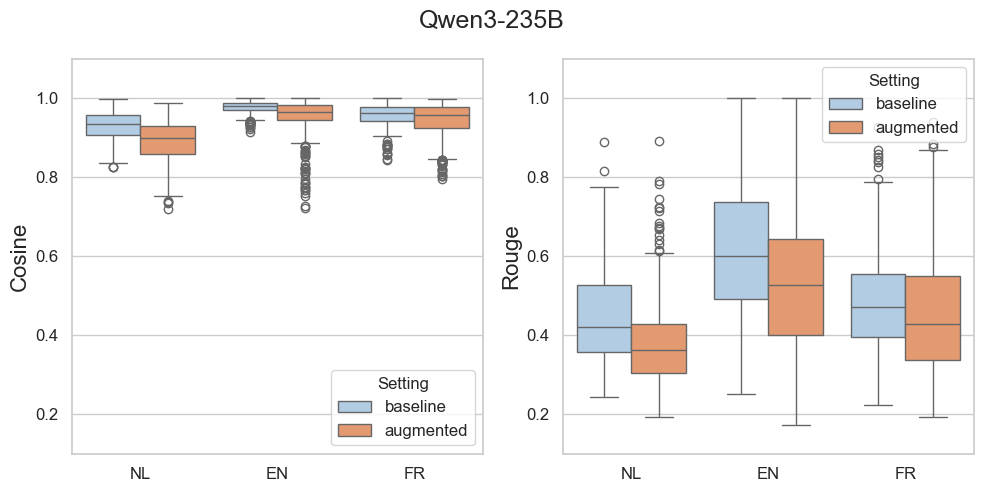

In [180]:
# std in scores amongst baseline answers and amongst augmented answers in a language per model
# same as above but not comparing between languages
import matplotlib.gridspec as gridspec

for model in models:
    fig, axs = plt.subplots(ncols=len(metrics), figsize=(10,5), sharey=False)
    test = within_baseline_prompt[(within_baseline_prompt["Model"]==model)]
    plt.suptitle(model)
    test["Setting"] = ["augmented" if x=="answers" else "baseline" for x in test["Answer"]]
    test = test.sort_values(by="Answer", ascending=False)
    for i in range(len(metrics)):
        axs[i].set_ylim([0.1,1.1])
        sns.boxplot(x=test["Language"].to_list(), y=metrics[i], hue="Setting", data=test, ax=axs[i],  palette=categorical)
        sns.move_legend(axs[i], "lower right")
        if i>0:
            sns.move_legend(axs[i], "upper right")
    plt.tight_layout()
    plt.show()

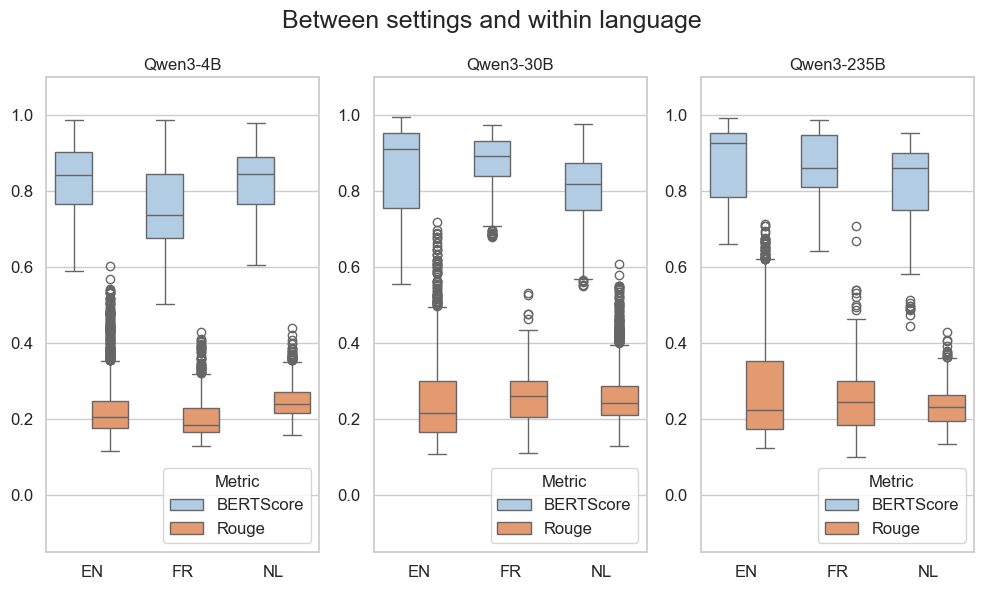

In [181]:
# std in scores between baseline condition and augmented condition per language per model

fig, axs = plt.subplots(ncols=len(models), figsize=(10, 6), sharey=False)
plt.suptitle('Between settings and within language')

for i, model in enumerate(models):
    axs[i].set_title(model)
    test = baseline_compare[baseline_compare["Model"]==model]
    test = test.rename(columns={"Cosine": "BERTScore"})
    test = test.melt(id_vars=["Model", "Question", "Language"], value_vars=["BERTScore", "Rouge"],value_name="", var_name="Metric")
    ax = sns.boxplot(data=test, x=test["Language"].to_list(), y="", hue="Metric", ax=axs[i], palette=categorical)
    axs[i].set_ylim([-0.15, 1.1])

plt.tight_layout()
plt.savefig('figs/between-setting-within-language.svg')
plt.show()

In [182]:
categorical = sns.color_palette([x for x in load_cmap(palette).colors if x!='#682C37FF'], 4)

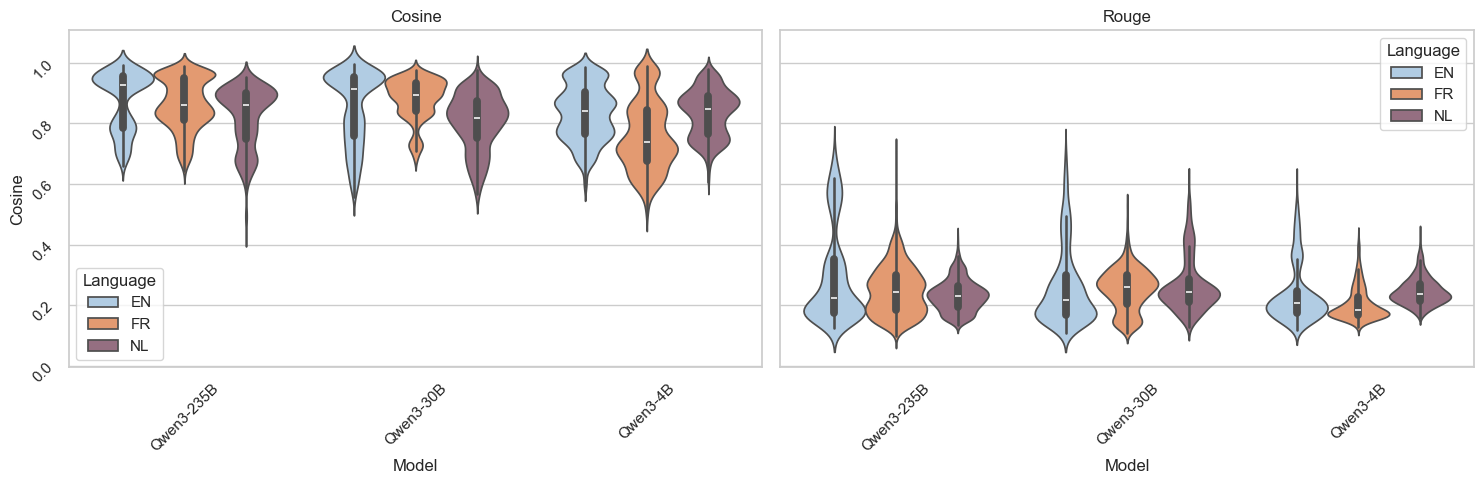

In [183]:
# violin plot of all questions, each subplot is one metric
# comparison of baseline1_lang_1 -> prompt1_lang_1, baseline1_lang_1 -> prompt2_lang1 and so on (agregate questions)
sns.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]
fig, axs = plt.subplots(ncols=len(ys), figsize=(15,5), sharey=True)

# not between questions, each violin plot has 24 data points
for i in range(len(ys)):
    axs[i].tick_params(labelrotation=45)   
    axs[i].title.set_text(ys[i])
    sns.violinplot(x="Model", 
                       y=ys[i], 
                       hue="Language",
                       data=baseline_compare,
                       density_norm='count',
                       ax=axs[i],
                    palette=categorical)
plt.tight_layout()

# Visualization of reranked/retrieved docs?

In [184]:
from datasets import load_from_disk 
import pickle
import re
import pandas as pd
import matplotlib.pyplot as plt

In [185]:
categorical = sns.color_palette([x for x in load_cmap(palette).colors if x!='#682C37FF'], 6)

In [186]:
answers = load_from_disk("all_answers")

answers = answers.to_pandas()

questions_NL = answers[answers["language"] == 'NL']["question"].unique()
questions_EN = answers[answers["language"] == 'EN']["question"].unique()
questions_FR = answers[answers["language"] == 'FR']["question"].unique()

question_map_NL = {questions_NL[f]: f"Question {f + 1}" for f in range(len(questions_NL))}
question_map_EN = {questions_EN[f]: f"Question {f + 1}" for f in range(len(questions_EN))}
question_map_FR = {questions_FR[f]: f"Question {f + 1}" for f in range(len(questions_FR))}

question_map = dict(question_map_NL, **question_map_EN, **question_map_FR)
print(question_map)
answers["question_mapped"] = [question_map[x] for x in answers["question"]]

with open("question_map.pkl", 'wb') as f:
    pickle.dump(question_map, f)

{'Wie was Napoleon Bonaparte?': 'Question 1', 'Was Napoleon Bonaparte een held?': 'Question 2', 'Was Napoleon Bonaparte een tiran?': 'Question 3', 'Was Napoleon Bonaparte een schurk?': 'Question 4', 'Hoe stichtte Napoleon Bonaparte zijn rijk in Europa?': 'Question 5', 'Hoe werd Napoleon Bonaparte keizer van Frankrijk?': 'Question 6', "Werd Napoleon Bonaparte's aanspraak op keizerschap in Europa gesteund?": 'Question 7', "Welke invloed had Napoleon Bonaparte's heerschappij op Engeland en Nederland?": 'Question 8', 'Wat was de impact van Napoleon Bonaparte op Engeland en Nederland?': 'Question 9', 'Was de impact van Napoleon Bonaparte op Engeland en Nederland destructief?': 'Question 10', 'Who was Napoleon Bonaparte?': 'Question 1', 'Was Napoleon Bonaparte a hero?': 'Question 2', 'Was Napoleon Bonaparte a tyrant?': 'Question 3', 'Was Napoleon Bonaparte a villain?': 'Question 4', 'How did Napoleon Bonaparte establish his empire in Europe?': 'Question 5', 'How did Napoleon Bonaparte become

In [187]:
answers.head()

,question,answers,baseline_answer,reranked_doc_ids,retrieved_doc_ids,language,model,question_mapped
0,Who was Napoleon Bonaparte?,[Napoleon Bonaparte was a French military and ...,[Napoleon Bonaparte was a French military lead...,"[american_stories957475, american_stories15622...","[blbooks1789933, american_stories733232, ameri...",EN,Qwen3-235B-A22B-Instruct-2507,Question 1
1,Was Napoleon Bonaparte a hero?,[Whether Napoleon Bonaparte was a hero depends...,[Whether Napoleon Bonaparte was a hero depends...,"[american_stories1562206, blbooks1789933, amer...","[american_stories1562206, american_stories7332...",EN,Qwen3-235B-A22B-Instruct-2507,Question 2
2,Was Napoleon Bonaparte a tyrant?,"[Yes, according to Document 0, Napoleon Bonapa...",[Whether Napoleon Bonaparte was a tyrant is a ...,"[blbooks1836403, american_stories1562206, amer...","[american_stories1562206, blbooks2049890, amer...",EN,Qwen3-235B-A22B-Instruct-2507,Question 3
3,Was Napoleon Bonaparte a villain?,[Napoleon Bonaparte cannot be simplistically l...,[Whether Napoleon Bonaparte was a villain depe...,"[american_stories1562206, american_stories1413...","[american_stories1562206, blbooks2049890, amer...",EN,Qwen3-235B-A22B-Instruct-2507,Question 4
4,How did Napoleon Bonaparte establish his empir...,[Napoleon Bonaparte established his empire in ...,[Napoleon Bonaparte established his empire in ...,"[blbooks1789933, american_stories957475, ameri...","[american_stories846451, american_stories13021...",EN,Qwen3-235B-A22B-Instruct-2507,Question 5


In [188]:
answers_subset = answers.drop(["answers", "baseline_answer", "question", "model"], axis=1)

In [189]:
answers_subset = answers_subset.drop_duplicates(subset=["language",'question_mapped'])

In [190]:
answers_subset

,reranked_doc_ids,retrieved_doc_ids,language,question_mapped
0,"[american_stories957475, american_stories15622...","[blbooks1789933, american_stories733232, ameri...",EN,Question 1
1,"[american_stories1562206, blbooks1789933, amer...","[american_stories1562206, american_stories7332...",EN,Question 2
2,"[blbooks1836403, american_stories1562206, amer...","[american_stories1562206, blbooks2049890, amer...",EN,Question 3
3,"[american_stories1562206, american_stories1413...","[american_stories1562206, blbooks2049890, amer...",EN,Question 4
4,"[blbooks1789933, american_stories957475, ameri...","[american_stories846451, american_stories13021...",EN,Question 5
5,"[blbooks1789933, american_stories957475, ameri...","[blbooks1789933, american_stories700895, ameri...",EN,Question 6
6,"[blbooks1789933, american_stories928114, ameri...","[american_stories1562206, american_stories7332...",EN,Question 7
7,"[american_stories1562206, american_stories8464...","[american_stories1562206, blbooks1852059, amer...",EN,Question 8
8,"[american_stories1562206, american_stories1464...","[american_stories1562206, american_stories8464...",EN,Question 9
9,"[delpher224220, american_stories1562206, ameri...","[american_stories1562206, american_stories6824...",EN,Question 10


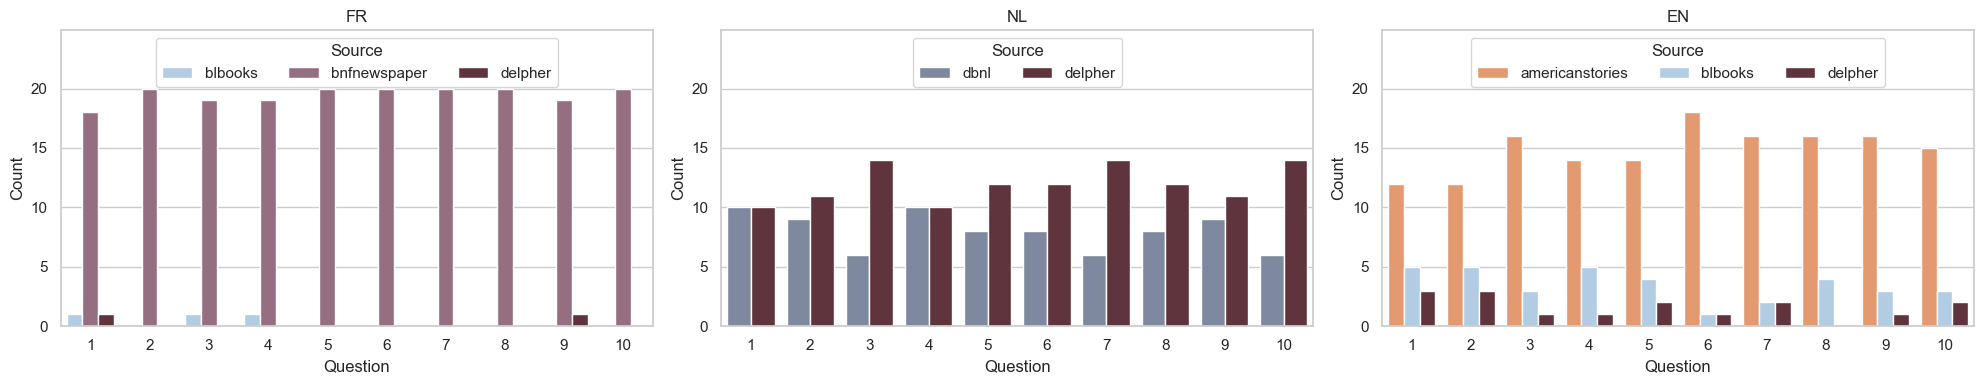

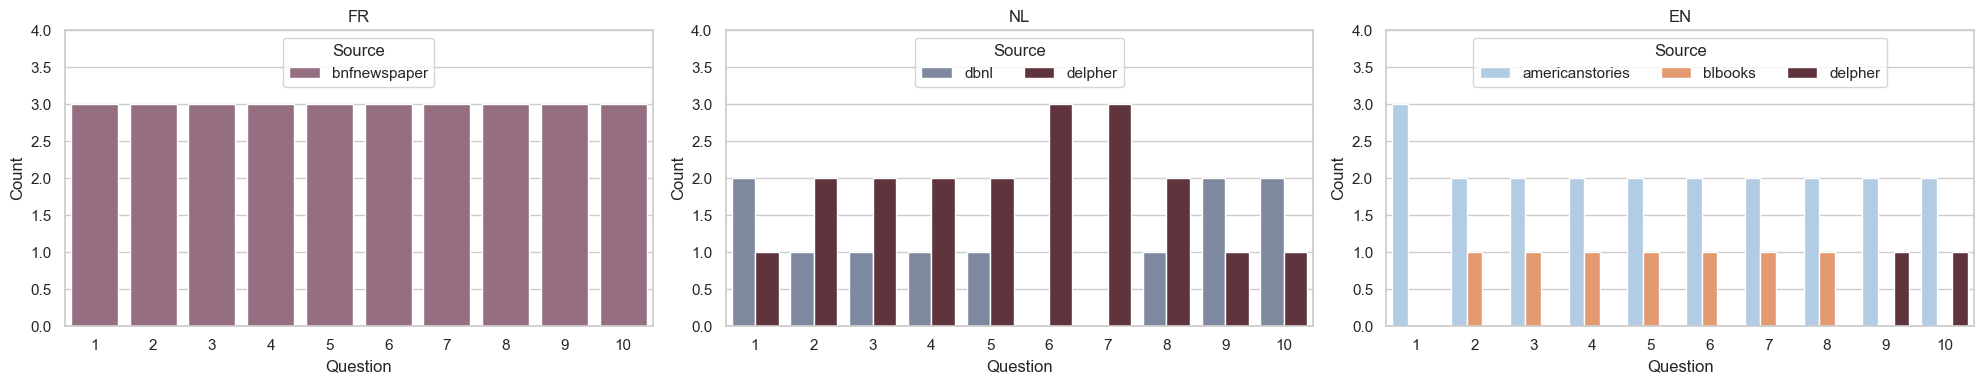

In [191]:
for j in ["retrieved_doc_ids", "reranked_doc_ids"]:
    retrieved = []
    language = []
    question = []

    for _, x in answers_subset.iterrows():
        list_ = [re.sub('[^a-zA-Z]+', '', s) for s in x[j]]
        retrieved.extend(list_)
        language.extend([x["language"]]*len(list_))
        question.extend([x['question_mapped']]*len(list_))
        
    df = pd.DataFrame({"Source":retrieved, "Question language": language, 'Question': question}) 
    df["Question"] = [int(x.split(" ")[1]) for x in df["Question"]]
    df["Count"] = 1
    color_map = {label: load_cmap(palette).colors[i] for i, label in enumerate(df['Source'].unique())}
    df = df.groupby(by=["Question", "Question language", "Source"]).agg("sum")
    df = df.reset_index()
    fig, axes = plt.subplots(1, 3, sharex=True, figsize=(20,4))
    # plt.suptitle("Retrieved" if "retrieved" in j else "Re-ranked")
    for i, language in enumerate(['FR', 'NL', 'EN']):
        subdf = df[df['Question language']==language]
        sns.barplot(ax=axes[i], x=subdf.Question, y=subdf.Count, hue=subdf.Source, palette=color_map, legend='brief')
        axes[i].set_title(language)
        axes[i].set_ylim([0,24.9] if "retrieved" in j else [0,4])
        sns.move_legend(axes[i], "upper center", ncol=3)
    plt.tight_layout()
    plt.savefig(f'figs/{j.split("_")[0]}.svg')
    plt.show()